# Syn Bank Share of Wallet Intelligence Engine

Ingestion + profiling only (PLAN.md Section 5, steps 1-3). No modeling logic yet.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA_DIR = Path.cwd()

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"Data directory: {DATA_DIR.resolve()}")

pandas 3.0.0 | numpy 2.2.1
Data directory: C:\Users\ADMIN\Downloads\Hackathon


## 2. Ingestion

Loads the 3 Syn Bank internal datasets. `transactional_banking.csv` is ~2.8M rows / ~390MB, so this cell may take a minute.

In [2]:
df_txn = pd.read_csv(DATA_DIR / "transactional_banking.csv", parse_dates=["date"])
df_xborder = pd.read_csv(DATA_DIR / "cross_border_payments.csv", parse_dates=["date"])
df_trade = pd.read_csv(DATA_DIR / "trade_finance.csv", parse_dates=["date"])

datasets = {
    "transactional_banking": df_txn,
    "cross_border_payments": df_xborder,
    "trade_finance": df_trade,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols")

transactional_banking: 2,802,875 rows x 13 cols
cross_border_payments: 241,117 rows x 13 cols
trade_finance: 20,303 rows x 15 cols


## 3. Profiling

For each dataset: row count, date range, unique entity counts, and null counts per column.

In [3]:
def profile(df: pd.DataFrame, name: str) -> None:
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(f"Rows: {len(df):,}")
    print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
    print(f"Unique entity_id: {df['entity_id'].nunique()}")
    print(f"Unique entity_name: {df['entity_name'].nunique()}")

    null_summary = pd.DataFrame({
        "null_count": df.isnull().sum(),
        "null_pct": (100 * df.isnull().mean()).round(2),
    })
    print("\nNull counts per column:")
    print(null_summary)
    print()


for name, df in datasets.items():
    profile(df, name)

transactional_banking
Rows: 2,802,875
Date range: 2023-07-01 -> 2026-06-30
Unique entity_id: 20


Unique entity_name: 20



Null counts per column:
                  null_count  null_pct
transaction_id             0      0.00
entity_id                  0      0.00
entity_name                0      0.00
sector                     0      0.00
date                       0      0.00
leg_type                   0      0.00
direction                  0      0.00
amount_zar                 0      0.00
currency                   0      0.00
channel                    0      0.00
beneficiary_name           0      0.00
reference                  0      0.00
memo                 2799218     99.87

cross_border_payments
Rows: 241,117


Date range: 2023-07-01 -> 2026-06-30
Unique entity_id: 20
Unique entity_name: 20

Null counts per column:
                      null_count  null_pct
transaction_id                 0      0.00
entity_id                      0      0.00
entity_name                    0      0.00
sector                         0      0.00
date                           0      0.00
direction                      0      0.00
currency_pair                  0      0.00
value_zar                      0      0.00
counterparty_country        3665      1.52
corridor_type                  0      0.00
beneficiary_name               0      0.00
reference                      0      0.00
memo                      240669     99.81

trade_finance
Rows: 20,303
Date range: 2023-07-01 -> 2026-06-30
Unique entity_id: 20
Unique entity_name: 20

Null counts per column:
                            null_count  null_pct
instrument_id                        0      0.00
entity_id                            0      0.00
entity_name

## 4. Entity list sanity check

Confirms the entities present in the data match the 20 names confirmed in PLAN.md Section 3.

In [4]:
PLAN_ENTITIES = {
    "Anglo American", "AngloGold Ashanti", "Aspen Pharmacare", "BHP Group",
    "Bid Corporation", "Clicks Group", "Glencore", "Gold Fields", "MTN Group",
    "NEPI Rockcastle", "Naspers", "OUTsurance Group", "Pepkor Holdings",
    "Prosus", "Sanlam", "Shaftesbury Capital plc", "Shoprite Holdings",
    "The Bidvest Group", "Valterra Platinum", "Vodacom Group",
}

data_entities = set()
for name, df in datasets.items():
    data_entities |= set(df["entity_name"].unique())

print(f"Entities found across all 3 datasets: {len(data_entities)}")
print(f"Entities listed in PLAN.md Section 3: {len(PLAN_ENTITIES)}")

missing_from_data = PLAN_ENTITIES - data_entities
extra_in_data = data_entities - PLAN_ENTITIES

if not missing_from_data and not extra_in_data:
    print("\nMATCH -- data entity list is identical to PLAN.md Section 3.")
else:
    print("\nMISMATCH")
    if missing_from_data:
        print(f"  In PLAN.md but not in data: {sorted(missing_from_data)}")
    if extra_in_data:
        print(f"  In data but not in PLAN.md: {sorted(extra_in_data)}")

for name, df in datasets.items():
    entities_here = set(df["entity_name"].unique())
    if entities_here != data_entities:
        print(f"NOTE: {name} does not cover all entities -- missing {data_entities - entities_here}")

Entities found across all 3 datasets: 20
Entities listed in PLAN.md Section 3: 20

MATCH -- data entity list is identical to PLAN.md Section 3.


## 5. Internal wallet share by product pillar

Per `docs/superpowers/specs/2026-08-08-pillar-spend-split-design.md` (approved): split each client's captured Syn Bank activity into the 3 product pillars — Transactional Banking, Trade & Working Capital, Foreign/Cross-Border — using the **trailing 12 months** (2025-07-01 → 2026-06-30) and **gross flow** (both directions summed).

Heavy lifting (loading the 2.8M-row `transactional_banking.csv`) lives in `scripts/build_pillar_spend.py` for speed/reproducibility — this notebook loads its output.

In [5]:
EXTRACTED_DIR = DATA_DIR / "hackathon-finreports" / "_extracted"

pillar_wide = pd.read_csv(EXTRACTED_DIR / "pillar_spend_wide.csv")
pillar_cols = ["Transactional Banking", "Trade & Working Capital", "Foreign / Cross-Border"]

print(f"{len(pillar_wide)} clients x 3 pillars, trailing 12mo gross flow (ZAR)")
pillar_wide[["entity_name", "sector"] + pillar_cols + ["total_internal_spend_zar"]].sort_values(
    "total_internal_spend_zar", ascending=False
)

20 clients x 3 pillars, trailing 12mo gross flow (ZAR)


,entity_name,sector,Transactional Banking,Trade & Working Capital,Foreign / Cross-Border,total_internal_spend_zar
10,Pepkor Holdings,consumer,3.419505e+10,1.533077e+09,6.655520e+09,4.238365e+10
7,Sanlam,insurance,1.924748e+10,1.523362e+08,2.664890e+09,2.206471e+10
9,Bid Corporation,consumer,1.292806e+10,1.878699e+09,6.165601e+09,2.097236e+10
0,BHP Group,mining,1.678772e+10,1.444550e+09,2.082856e+09,2.031512e+10
15,MTN Group,telecoms,1.043628e+10,1.443169e+09,6.209646e+09,1.808910e+10
8,Shoprite Holdings,consumer,1.059335e+10,1.539091e+09,3.356218e+09,1.548866e+10
2,Anglo American,mining,7.557961e+09,6.320166e+08,9.963789e+08,9.186357e+09
1,Glencore,mining,4.440268e+09,1.085074e+09,2.323926e+09,7.849268e+09
17,The Bidvest Group,industrials_pharma,4.730574e+09,1.464031e+09,1.614258e+09,7.808863e+09
18,Aspen Pharmacare,industrials_pharma,3.552116e+09,5.324227e+08,1.412987e+09,5.497526e+09


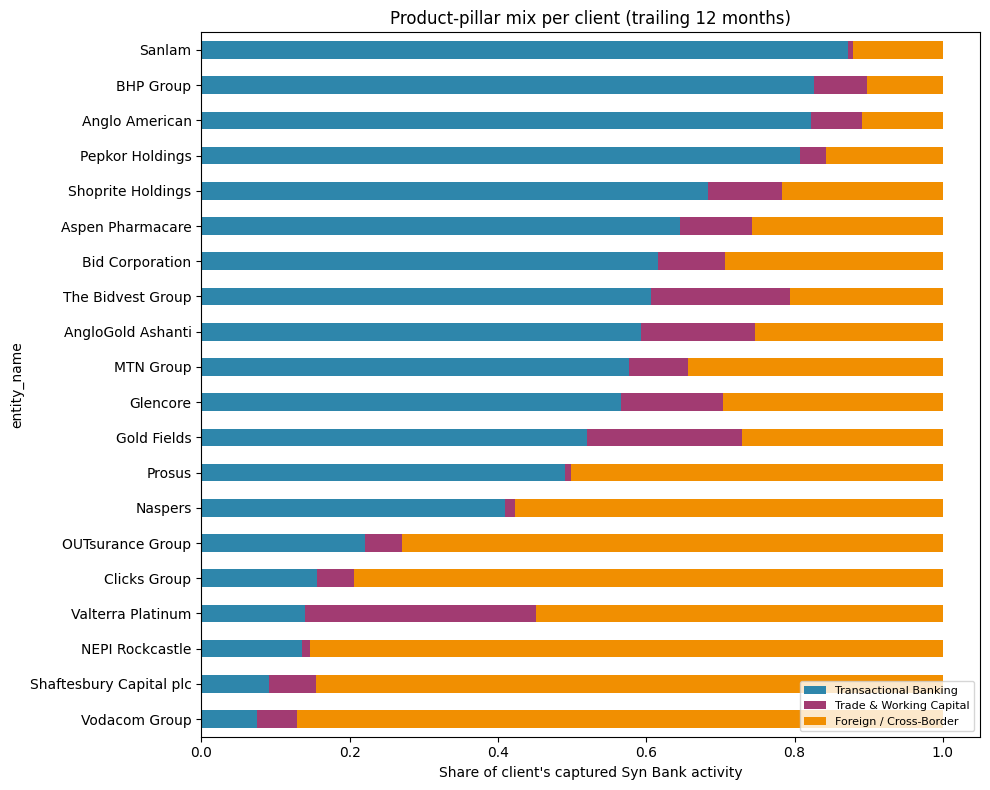

In [6]:
pct_cols = [f"{c} % of total" for c in pillar_cols]
plot_df = pillar_wide.set_index("entity_name")[pct_cols].sort_values(pct_cols[0])

fig, ax = plt.subplots(figsize=(10, 8))
plot_df.plot(kind="barh", stacked=True, ax=ax, color=["#2E86AB", "#A23B72", "#F18F01"])
ax.set_xlabel("Share of client's captured Syn Bank activity")
ax.set_title("Product-pillar mix per client (trailing 12 months)")
ax.legend(pillar_cols, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 6-7. External wallet estimation (top-down) + Wallet model

**Scope decision (solo build, time-constrained):** top-down financials-based Total Wallet proxy only — bottom-up competitor evidence (SARB BA900, JSE SENS) was cut from this pass, see `DATA_SOURCES.md`. Full methodology and the reliability-tiering fix (see below) are documented in `docs/reports/2026-08-13-wallet-model-summary.md`.

**Important caveat surfaced by this model, not hidden:** a naive proxy (= consolidated group revenue) produces a nonsensical multi-trillion-Rand "gap" for globally-diversified multinationals (Glencore, BHP, Anglo American, etc.) because their group revenue reflects *worldwide* operations, not the SA-specific slice Syn Bank could plausibly capture. Every row below is tagged with `top_down_reliability`:
- `moderate` — ZAR reporter, figures are for the SA-listed entity itself, Rand gap is reasonably literal.
- `low` — foreign-currency (USD/EUR/GBP) reporter, Rand gap is directional only, don't sum into a portfolio total.
- `insufficient` — Bidvest: only company-level (not Group) AFS was ever found, Pillar 1 wallet unknown, blended total correctly left blank.

In [7]:
wallet_model = pd.read_csv(EXTRACTED_DIR / "wallet_model.csv")

display_cols = [
    "entity_name", "sector", "top_down_reliability",
    "share_pct_pillar1", "share_pct_pillar2", "share_pct_pillar3",
    "total_internal_zar_m", "total_wallet_zar_m", "blended_share_pct", "total_gap_zar_m",
]
wallet_model[display_cols].sort_values("total_gap_zar_m", ascending=False, na_position="last")

,entity_name,sector,top_down_reliability,share_pct_pillar1,share_pct_pillar2,share_pct_pillar3,total_internal_zar_m,total_wallet_zar_m,blended_share_pct,total_gap_zar_m
0,Glencore,mining,low - foreign reporting currency; consolidated...,0.1,0.1,NaN,7849.267800,9.508822e+06,0.1,9500972.7
1,BHP Group,mining,low - foreign reporting currency; consolidated...,2.0,0.5,NaN,20315.123914,1.128830e+06,1.8,1108515.0
2,Anglo American,mining,low - foreign reporting currency; consolidated...,2.5,0.3,NaN,9186.356661,5.119176e+05,1.8,502731.2
3,Shoprite Holdings,consumer,"moderate - ZAR reporter, financials are for th...",2.4,2.7,NaN,15488.659043,5.056690e+05,3.1,490180.3
4,Bid Corporation,consumer,"moderate - ZAR reporter, financials are for th...",3.1,2.3,NaN,20972.361438,4.944375e+05,4.2,473465.1
5,MTN Group,telecoms,"moderate - ZAR reporter, financials are for th...",4.6,NaN,3.5,18089.100089,4.062589e+05,4.5,388169.8
6,Naspers,tech,low - foreign reporting currency; consolidated...,0.8,0.3,2.1,3557.985676,3.020283e+05,1.2,298470.3
7,AngloGold Ashanti,mining,low - foreign reporting currency; consolidated...,0.8,1.1,NaN,3346.136740,2.913841e+05,1.1,288038.0
8,Vodacom Group,telecoms,"moderate - ZAR reporter, financials are for th...",0.2,0.2,4.7,3341.054273,2.889873e+05,1.2,285646.2
9,Valterra Platinum,mining,"moderate - ZAR reporter, financials are for th...",0.0,0.2,NaN,369.484073,2.630510e+05,0.1,262681.5


## 8. Opportunity ranking

Ranked by total Rand gap. Split into the **actionable tier** (ZAR reporters — read the Rand figure literally) vs. the full list (includes low-reliability multinational rows, where only the % share is trustworthy).

=== Actionable tier - top opportunities by Rand gap (ZAR reporters only) ===
      entity_name             sector data_vintage_flag  total_internal_zar_m  total_wallet_zar_m  blended_share_pct  total_gap_zar_m
Shoprite Holdings           consumer           current          15488.659043         505669.0000                3.1         490180.3
  Bid Corporation           consumer           current          20972.361438         494437.5000                4.2         473465.1
        MTN Group           telecoms           current          18089.100089         406258.9440                4.5         388169.8
    Vodacom Group           telecoms           current           3341.054273         288987.2755                1.2         285646.2
Valterra Platinum             mining           current            369.484073         263051.0000                0.1         262681.5
  Pepkor Holdings           consumer           current          42383.649761         202842.0000               20.9         1

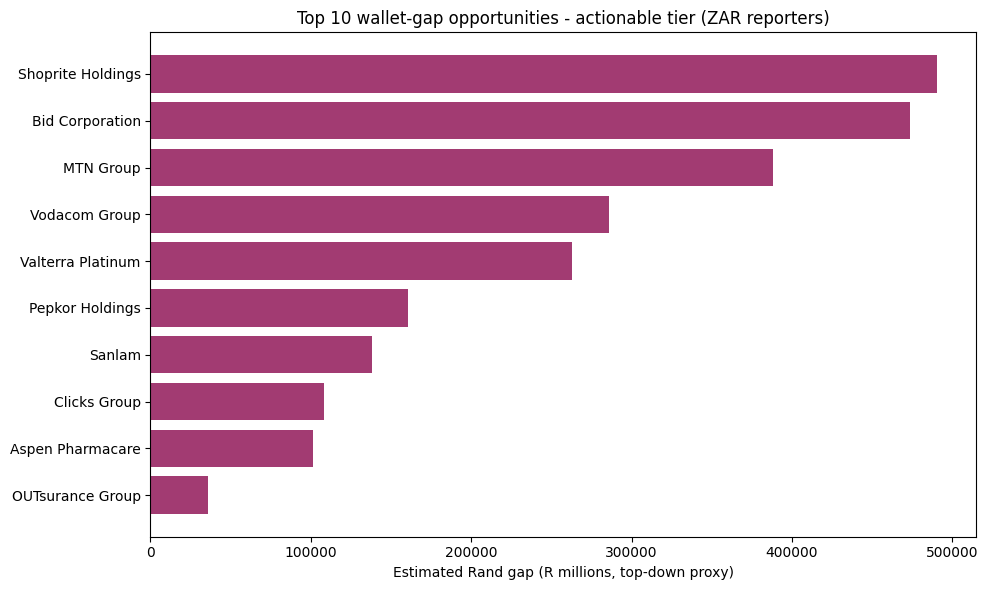

In [8]:
ranking = pd.read_csv(EXTRACTED_DIR / "opportunity_ranking.csv")
actionable = ranking[ranking["top_down_reliability"].str.startswith("moderate")].copy()

print("=== Actionable tier - top opportunities by Rand gap (ZAR reporters only) ===")
display_ranking_cols = ["entity_name", "sector", "data_vintage_flag", "total_internal_zar_m", "total_wallet_zar_m", "blended_share_pct", "total_gap_zar_m"]
print(actionable[display_ranking_cols].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top10 = actionable.head(10).sort_values("total_gap_zar_m")
ax.barh(top10["entity_name"], top10["total_gap_zar_m"], color="#A23B72")
ax.set_xlabel("Estimated Rand gap (R millions, top-down proxy)")
ax.set_title("Top 10 wallet-gap opportunities - actionable tier (ZAR reporters)")
plt.tight_layout()
plt.show()

## 9. GenAI layer — client briefing notes

Satisfies the "Layers in Generative AI" requirement (`PLAN.md` Section 1.4) and the "AI briefing notes for ≥3 clients" deliverable — see `docs/genai/README.md` for how all three required GenAI use cases (briefing notes, anomaly explanations in Section 11, NL querying in Section 11) fit together as one coherent layer, not three disconnected add-ons.

Notes were generated by applying a documented, reusable prompt template directly against each client's row in `wallet_model.csv` — see `docs/genai/briefing_note_prompt.md` for the exact prompt and rationale. The prompt is deliberately constrained: it forbids inventing numbers (arithmetic is already done deterministically upstream) and forces the model to state the `top_down_reliability` caveat plainly whenever it isn't "moderate" — this is what makes it correctly flag cases like Glencore's naive multi-trillion-Rand "gap" as a reliability artifact rather than report it at face value.

**All 20/20 clients** are covered (full portfolio, not a curated sample), ordered by total Rand gap. Every numeric claim in every note is machine-verified against `wallet_model.csv` by `scripts/verify_briefing_notes.py` — this caught one real error during development (a stale FY2024 figure quoted instead of FY2025) before it reached a reviewer. See the verification cell below the notes.

In [9]:
from IPython.display import Markdown, display

briefing_notes_path = EXTRACTED_DIR / "client_briefing_notes.md"
display(Markdown(briefing_notes_path.read_text(encoding="utf-8")))

# Client Briefing Notes — GenAI-Generated

**Generated using:** the prompt template in `docs/genai/briefing_note_prompt.md`, applied against every row of `wallet_model.csv` / `opportunity_ranking.csv` — all 20 clients covered.
**Source data as of:** FY2025 (see `data_vintage_flag` in source tables); all Rand figures in ZAR millions unless stated.
**Grounding check:** every numeric claim below is machine-verified against `wallet_model.csv` by `scripts/verify_briefing_notes.py` (see `hackathon-finreports/_extracted/briefing_notes_verification.csv` for the full audit trail — 0 unresolved discrepancies as of the last run).
**Ordered by:** total Rand gap, descending (same order as `opportunity_ranking.csv`).

---

## 1. Glencore — do not read this Rand gap literally
*Sector: Mining (global commodity trader) | Reliability: LOW — see caveat before using this figure anywhere*

Glencore reports in USD as a global commodity trader; its consolidated group revenue (used as the top-down wallet proxy) reflects **worldwide trading operations**, not an SA-specific banking relationship any single bank could plausibly capture. The raw output here — a **R9.5 trillion "gap"**, 0.1% share — is the naive-model trap this analysis is specifically designed to catch, not a real finding. A dashboard that reported this at face value would send a coverage banker chasing a fictional multi-trillion-Rand opportunity. **Read only the direction** (share is genuinely very low, consistent with limited SA-specific penetration) — not the Rand magnitude. Recommend excluding Glencore-type multinational rows from any portfolio-level Rand-gap totals in the executive summary, and footnoting this explicitly in the presentation as a modeling caveat worth surfacing to judges in its own right.

---

## 2. BHP Group
*Sector: Mining | Reliability: LOW — foreign reporting currency, read the Rand gap as directional only*

Global diversified miner reporting in USD — among the largest low-reliability rows in the portfolio, so treat the Rand gap as directional only (consolidated group revenue reflects worldwide iron ore/copper/coal operations, not an SA-specific relationship). Transactional share is **2.0%** (R819.9bn gap on an R836.7bn wallet) and trade & working-capital share is **0.5%** (R290.7bn gap on R292.2bn); cross-border wallet wasn't estimated. Blended share is **1.8%**, though the **R1.11 trillion** blended gap should not be read as a real addressable number — it's an artifact of comparing SA-based internal flow to BHP's entire global revenue base. Given the low-reliability flag, don't lead with a Rand figure in a coverage conversation; the real question is what slice of BHP's actual South African operations Syn Bank could plausibly capture, which this proxy cannot answer.

---

## 3. Anglo American
*Sector: Mining | Reliability: LOW — foreign reporting currency*

Global mining major reporting in USD — same caveat as BHP: consolidated revenue covers copper, iron ore, and diamond operations worldwide, not a single-country relationship. Transactional share is **2.5%** (R294.9bn gap on an R302.5bn wallet); trade & working-capital share is thinner still at **0.3%** (R208.8bn gap on R209.4bn) despite Anglo American clearly running large working-capital financing needs across its operations. Cross-border wallet wasn't estimated. Blended share is **1.8%**, with a **R502.7bn** combined gap that is directional evidence of low SA-specific penetration, not a literal addressable pool. Recommend a research priority to identify Anglo American's SA-domiciled subsidiary financials specifically (the same way Valterra Platinum was carved out of Anglo American Platinum) before quoting any Rand figure to a banker or judge.

---

## 4. Shoprite Holdings
*Sector: Consumer retail | Reliability: moderate (ZAR reporter, literal figures)*

South Africa's largest domestic grocery retailer, and a ZAR reporter — so this Rand gap is literal, not directional. Syn Bank currently captures just **2.4%** of the estimated R448bn transactional banking wallet (based on group revenue + cost of sales) — a **R437bn gap** — and a similarly thin **2.7%** of the R57.7bn trade & working-capital wallet. Foreign/cross-border wallet wasn't estimated (no disclosed foreign-revenue split), though Shoprite's inventory and receivables scale suggest genuine domestic trade-finance need beyond what's visible here. Given the retailer's high-volume, high-frequency payment profile, lead the next coverage conversation with **transactional banking** (payments/collections infrastructure) rather than trade finance — the addressable gap there is 8x larger, and a strong day-to-day banking relationship is the easier wedge into deepening trade & working capital afterward.

---

## 5. Bid Corporation
*Sector: Consumer / global foodservice distribution | Reliability: moderate*

Global foodservice distribution group, ZAR reporter with literal Rand figures. Captures only **3.1%** of an estimated R413.5bn transactional wallet (**R400.6bn gap**) and **2.3%** of a R80.9bn trade & working-capital wallet — both pillars are almost entirely untapped despite Bid Corp's scale. No cross-border wallet estimate is available (foreign-revenue split not disclosed), so the true multinational trade-finance opportunity is likely understated here. Foodservice distribution runs on high inventory turnover and supplier financing, making this a strong trade-finance pitch as well as a transactional one — recommend a **joint transactional-plus-trade proposal** rather than leading with one pillar alone, since both show comparably low penetration.

---

## 6. MTN Group
*Sector: Telecoms | Reliability: moderate*

Africa-focused telecom, ZAR reporter, Rand figures are literal. Transactional banking share is **4.6%** (R216.3bn gap on a R226.7bn wallet), and — notably — MTN is one of only 4/20 companies where a **cross-border wallet could be estimated at all**, thanks to a disclosed foreign-revenue split (79.2% of revenue is non-SA in FY2025). Cross-border share sits at **3.5%** (R173.3bn gap). Trade & working-capital wallet couldn't be estimated this year (a data gap in the source financials, not a real zero — don't read it as "no opportunity"). Recommendation: MTN is the **strongest cross-border pitch in the portfolio** — pan-African operations plus a disclosed majority-foreign revenue base make FX/correspondent banking the highest-conviction lead, ahead of transactional.

---

## 7. Naspers
*Sector: Technology / internet holding group | Reliability: LOW — foreign reporting currency*

Global internet/tech holding group reporting in USD — low reliability, consolidated figures span e-commerce and classifieds businesses across dozens of countries via its structure. Transactional share is **0.8%** (R185.7bn gap on a R187.2bn wallet) and trade & working-capital share is **0.3%** (R15.1bn gap on R15.1bn). The standout number: Naspers is one of only 4/20 companies with a disclosed, usable foreign-revenue split (**85.1%** of revenue is non-SA), giving a cross-border share of **2.1%** on a R99.7bn wallet (R97.6bn gap) — a real, if thin, cross-border relationship. Blended share is **1.2%** (R298.5bn gap, directional only given the low-reliability flag). Recommend leading with cross-border/FX — it's the only pillar here with a genuinely comparable external benchmark for a near-entirely-offshore business.

---

## 8. AngloGold Ashanti
*Sector: Mining | Reliability: LOW — foreign reporting currency*

Global gold miner reporting in USD — low reliability, same consolidation caveat as the other multinational miners in this portfolio. Transactional share is **0.8%** (R241.5bn gap on a R243.4bn wallet) and trade & working-capital share is **1.1%** (R47.4bn gap on R48.0bn) — both thin, but directionally consistent with a foreign-currency reporter whose group revenue spans mines across the Americas, Africa, and Australia, not an SA-specific book. Cross-border wasn't estimated this year (no disclosed foreign-revenue split). Blended share is **1.1%**, with a R288.0bn combined gap that should be read as "very low penetration, direction confirmed" rather than a literal figure to sum into a portfolio total. Worth noting alongside Gold Fields (also a low-reliability gold miner with a similarly thin ~1% blended share) as a sector-level pattern.

---

## 9. Vodacom Group
*Sector: Telecoms | Reliability: moderate*

ZAR reporter, literal Rand figures. Transactional (**0.2%**) and trade & working-capital (**0.2%**) shares are both near-zero — a pattern similar to Valterra Platinum, worth flagging as genuine under-penetration rather than a scale artifact. The one bright spot: cross-border share is **4.7%** (the best pillar-level result in the whole cross-border comparison set, which only covers 4/20 companies), on a disclosed 40.7% foreign-revenue base. Recommendation: use the existing cross-border relationship as the **entry point to cross-sell transactional banking** — Vodacom already trusts Syn Bank with FX/cross-border flow, normally the harder sell, so the transactional gap looks more like a sales-sequencing gap than a competitive lock-in.

---

## 10. Valterra Platinum — flag this one specifically
*Sector: Mining | Reliability: moderate (ZAR reporter — this is a real finding, not a scale artifact)*

Unlike the multinational miners in this portfolio (Glencore, BHP, Anglo American), Valterra is a **ZAR reporter** — its financials ARE the SA entity, so the near-zero share below isn't a currency/consolidation artifact. Syn Bank's share is effectively zero across every pillar measured: **0.0%** of a R204bn transactional wallet, **0.2%** of a R59bn trade & working-capital wallet. This is the sharpest single-client finding in the whole dataset — a domestic, ZAR-reporting mining major with almost no visible Syn Bank banking relationship at all. Recommend prioritizing Valterra for a **full relationship review** ahead of the more diluted 2–4% opportunities elsewhere in the portfolio; the near-total absence of activity here is itself worth investigating (exclusive competitor relationship? recent listing following the Anglo American Platinum spin-off?) before assuming it's purely a sales-effort gap.

---

## 11. Gold Fields
*Sector: Mining | Reliability: LOW — foreign reporting currency*

Global gold miner reporting in USD — low reliability. This is the entity whose FY2025 figures were manually re-pulled and corrected earlier in the project (an initial pass had stale FY2023 data understating revenue by roughly half) — the numbers below reflect the corrected, current-year filing. Transactional share is **0.9%** (R201.2bn gap on a R202.9bn wallet) and trade & working-capital share is **1.7%** (R39.2bn gap on R39.9bn) — the best pillar-2 result among the low-reliability gold/mining peer set (AngloGold, Anglo American), suggesting a comparatively more active trade-finance relationship even though transactional banking is barely present. Cross-border wasn't estimated. Blended share is **1.4%** (R239.5bn gap, directional only). Recommend using the corrected, current data as the baseline for any Gold Fields conversation going forward, and treat trade & working-capital, not transactional, as the stronger relative lead.

---

## 12. Prosus
*Sector: Technology / e-commerce | Reliability: LOW — foreign reporting currency*

Naspers' internationally-listed e-commerce arm, reporting in USD — low reliability, same global-consolidation caveat. Transactional share is **1.2%** (R156.6bn gap on a R158.6bn wallet) and trade & working-capital share is **0.3%** (R12.6bn gap on R12.6bn). Unlike its parent Naspers, no usable foreign-revenue split was disclosed for Prosus this year, so cross-border wallet isn't estimated here despite Prosus being, if anything, an even more globally-diversified business (food delivery, classifieds, fintech across Europe, Asia, and Latin America). Blended share is **2.3%** (R167.3bn gap, directional only). Recommend treating Naspers and Prosus as a single relationship story in any pitch rather than two separate low-conviction lines — only Naspers currently has a disclosed cross-border benchmark, and that finding should carry across to how Prosus's undisclosed but plausibly larger cross-border activity is framed.

---

## 13. Pepkor Holdings — deepen, don't chase
*Sector: Consumer retail | Reliability: moderate*

South Africa's largest clothing/general-merchandise retail group, ZAR reporter — this Rand gap is literal. Pepkor stands out immediately: **22.4%** transactional share is the best result anywhere in the 20-company portfolio bar Sanlam, and still leaves a genuine **R118.5bn** wallet gap on a R152.7bn transactional base. Trade & working-capital tells a very different story at just **3.1%** share (R48.6bn gap on R50.1bn) — a high-volume retailer with this much inventory and supplier-payment activity almost certainly needs more trade finance than is currently captured. Cross-border wasn't estimated. Blended share is **20.9%** (R160.5bn gap). Recommendation: this relationship is already strong on transactional — the next coverage conversation should specifically pitch **trade & working-capital / supply-chain finance**, where the gap relative to Pepkor's scale is largest.

---

## 14. Sanlam — read the cross-border number with a caveat
*Sector: Insurance | Reliability: moderate, but one pillar needs context*

Already **Syn Bank's best-penetrated relationship in the portfolio** at 18.7% transactional share (vs. 0.1–5% for most other clients) — R83.7bn of a R102.9bn wallet still open. One number needs an asterisk, not a fix: cross-border "share" shows as **133.5%** (internal flow of R2.66bn against a R2.0bn top-down proxy). This isn't a data error — it reflects that the proxy (revenue × disclosed foreign-revenue%) doesn't capture an insurer's treasury/FX turnover, which runs far larger than trading revenue alone would suggest. Recommendation: the real actionable opportunity is **trade & working-capital**, still at just 0.3% share despite an 18.7%-penetrated transactional relationship — pursue that gap; don't chase the inflated cross-border number.

---

## 15. Clicks Group — the second Valterra
*Sector: Consumer retail (pharmacy / health & beauty) | Reliability: moderate*

Domestic pharmacy/health & beauty retailer, ZAR reporter — this Rand gap is literal, not directional. Like Valterra Platinum, Clicks is a case where near-zero share is a real finding, not a currency-consolidation artifact: transactional share is **0.2%** (R87.7bn gap on an R87.9bn wallet) and trade & working-capital share is **0.3%** (R21.8bn gap on R21.9bn) — both pillars are almost entirely untapped for a well-established, high-footfall domestic retailer. Cross-border wasn't estimated. Blended share is **1.2%** (R108.5bn gap). Recommendation: prioritize Clicks for a full relationship review alongside Valterra — a domestic ZAR reporter with essentially no visible Syn Bank activity across either measured pillar is a stronger, more defensible sales-effort case than the diluted 2–5% opportunities found elsewhere in the portfolio.

---

## 16. Aspen Pharmacare
*Sector: Pharmaceuticals | Reliability: moderate*

Specialty pharmaceutical manufacturer, ZAR reporter — literal Rand figures. Transactional share is **5.3%** (R64.0bn gap on an R67.6bn wallet) — one of the better-penetrated transactional relationships in the portfolio, behind only Pepkor and Sanlam — while trade & working-capital lags well behind at **1.4%** share (R38.8bn gap on R39.3bn). Cross-border wasn't estimated despite Aspen's known international manufacturing and distribution footprint, which is worth flagging as a research gap rather than a real zero. Blended share is **5.1%** (R101.4bn gap). Recommendation: given transactional banking is already comparatively strong, lead the next conversation with **trade & working-capital** — pharmaceutical manufacturing runs on long inventory and receivables cycles that this proxy shows as almost entirely unfinanced by Syn Bank today.

---

## 17. OUTsurance Group — ignore the trade & working-capital number
*Sector: Insurance | Reliability: moderate overall, one pillar flagged*

Short-term insurer, ZAR reporter — moderate reliability overall, but one number needs a clear caveat before use. Transactional share is **0.9%** (R36.8bn gap on an R37.1bn wallet), a real and usable figure. Trade & working-capital shows an anomalous **491%** "share" — not a data error, but a proxy breakdown: an insurer holds almost no inventory or trade receivables/payables (the R16.0m wallet estimate is essentially a rounding artifact of a working-capital proxy applied to a balance sheet that isn't built that way), while genuine internal treasury/float activity of R78.6m dwarfs it. Cross-border wallet also wasn't estimated. Blended share of **4.2%** is still reasonable, since the tiny pillar-2 wallet barely moves it. Recommendation: ignore the trade & working-capital figure entirely for OUTsurance and focus the pitch on transactional banking, the only pillar with a trustworthy external benchmark for an insurer.

---

## 18. NEPI Rockcastle
*Sector: Real estate (CEE shopping-centre REIT) | Reliability: LOW — foreign reporting currency*

Central and Eastern European shopping-centre REIT, reports in EUR — low reliability; consolidated figures cover a property portfolio spread across Romania, Poland, and several other CEE markets, not South Africa, despite being JSE-listed. Transactional share is **0.4%** and trade & working-capital share is **0.1%** — both pillars show a roughly R11.7bn and R5.5bn gap respectively, but internal capture is genuinely tiny (R48m and R4m) rather than the wallet estimate being unusually large — consistent with a business whose core banking relationships (property financing, cross-border rental income) likely sit with European banks close to the underlying assets. Cross-border wasn't estimated. Blended share is **2.1%** (R16.9bn gap, directional only). Recommendation: treat NEPI Rockcastle as a lower coverage priority than the domestic ZAR reporters in this portfolio — the smallest absolute Rand gap of the low-reliability group, combined with the currency/geography mismatch, suggests limited realistic upside relative to effort required.

---

## 19. Shaftesbury Capital plc
*Sector: Real estate (UK West End REIT) | Reliability: LOW — foreign reporting currency*

UK-listed West End London real-estate REIT, reports in GBP — low reliability, and a genuinely unusual case: Shaftesbury discloses **0% foreign revenue** (its entire portfolio is UK property), which would make any cross-border wallet proxy exactly zero rather than simply "not estimated" — handled explicitly in the multi-year model as a zero-wallet edge case rather than silently producing an infinite share. Transactional share is **0.3%** and trade & working-capital share is **0.2%** — both the smallest absolute Rand gaps in the whole portfolio (R4.7bn and R5.5bn respectively), since internal capture here is only R12m and R8m. Blended share is **1.3%** (R10.2bn gap). Recommendation: this is the lowest-priority client in the portfolio for a South African bank — a 100% UK-domestic property business has little structural reason to deepen a Syn Bank relationship, and the small absolute gap confirms there's limited realistic upside here.

---

## 20. The Bidvest Group — cannot be reliably assessed on current data
*Sector: Industrials / diversified services | Reliability: INSUFFICIENT — see caveat, no blended total computed*

Diversified industrials/services group, ZAR reporter — but flagged **insufficient**, not moderate: only company-level (not Group) annual financial statements were located in the source filing, so Group revenue — and therefore the entire transactional wallet estimate — is unknown, not zero. Rather than compute a misleadingly partial blended total from 2 of 3 pillars, it's correctly left blank. The one pillar that is available, trade & working-capital, shows an anomalous **666%** "share" (an internal flow of R1.46bn against a R219.8m wallet built from company-level, not Group-level, working capital) — a proxy-scale mismatch, not a genuine relationship strength, and shouldn't be read as a positive finding. Notably, a 27.9% foreign-revenue split IS disclosed elsewhere in Bidvest's filings, so cross-border activity is real but still can't be sized without Group revenue. Recommendation: before any coverage conversation, source Bidvest's full Group AFS (not the entity-level filing used here) — this client cannot be reliably assessed on the current data at all.

---

*Methodology, full prompt template, and rationale: `docs/genai/briefing_note_prompt.md`. Grounding verification: `scripts/verify_briefing_notes.py` / `briefing_notes_verification.csv`.*


In [10]:
import sys

sys.path.insert(0, str(DATA_DIR / "scripts"))
from verify_briefing_notes import main as verify_briefing_notes

print("Grounding check: every % and Rand figure stated in the briefing notes above, cross-checked against wallet_model.csv\n")
verify_briefing_notes()

Grounding check: every % and Rand figure stated in the briefing notes above, cross-checked against wallet_model.csv

Checked 143 numeric claims across 20 clients

  [PASS] Anglo American: 8/8 numeric claims verified against source data
  [PASS] AngloGold Ashanti: 9/9 numeric claims verified against source data
  [PASS] Aspen Pharmacare: 8/8 numeric claims verified against source data
  [PASS] BHP Group: 8/8 numeric claims verified against source data
  [PASS] Bid Corporation: 5/5 numeric claims verified against source data
  [PASS] Clicks Group: 9/9 numeric claims verified against source data
  [PASS] Glencore: 2/2 numeric claims verified against source data
  [PASS] Gold Fields: 8/8 numeric claims verified against source data
  [PASS] MTN Group: 6/6 numeric claims verified against source data
  [PASS] NEPI Rockcastle: 8/8 numeric claims verified against source data
  [PASS] Naspers: 12/12 numeric claims verified against source data
  [PASS] OUTsurance Group: 7/7 numeric claims verifie

## 10. ML-based Share of Wallet prediction

Complements the top-down deterministic wallet model (Sections 6-7) with a learned model (`machine_learning/elastic_net.py`): **ElasticNet regression** (L1 + L2 regularization), trained per-target on internal Syn Bank activity (collections, supplier payments, trade receivables/payables, cross-border inflows), predicting what % share of the client's *external* total those internal figures represent - across the fiscal-year-aligned company-year panel from `medallion-pipeline/`.

**Why ElasticNet over the earlier Ridge version:** with only 17-39 rows and 1-2 features per pillar, Ridge (L2-only) is forced to keep every feature at some shrunk weight. ElasticNet's L1 component can zero out a feature that adds only noise, which is exactly what happened here - it out-performed Ridge on every target that has any real signal at all (Trade Receivables/Payables, Transactional Revenue/Cost).

**Why 5 sub-models, not 3:** Trade and Transactional each predict two genuinely different targets (e.g. receivables share vs. payables share) that don't necessarily correlate - a single multi-output regressor would force them to share one set of coefficients. Each is now its own independently-tuned ElasticNet estimator, packaged as one bundle per pillar (`trade_model.pkl` = `{receivables_model, payables_model, ...}`, same for transactional; FX has one target so stays a single model).

**Why Leave-One-Group-Out (LOGO) CV instead of a single train/test split:** the previous Ridge version held out a random 20% of rows once, giving a test set as small as 3-7 rows - too small to trust. LOGO instead holds out *every company* exactly once (refitting on the rest each time), giving one honest out-of-fold prediction per row across the *entire* panel (17-39 points, not 3-7) with zero data leakage (the scaler is refit inside each fold). This is a meaningfully more rigorous evaluation for a dataset this size, and the R² values below are computed this way - not just on a lucky/unlucky random split.

**Read the R² honestly:** 4 of 5 targets land at R²=0.24-0.39 (Trade Receivables, Trade Payables, Transactional Revenue, Transactional Cost) - a genuinely respectable result given the sample size. FX stays negative (worse than predicting the mean) across every hyperparameter combination tried, consistent with a known data limitation, not a modeling failure: only 17 of 43 company-years have a disclosed, usable `foreign_revenue_pct` to train against at all.

In [11]:
import sys
import io
import contextlib
import joblib
from sklearn.metrics import r2_score

MODELS_DIR = DATA_DIR / "machine_learning" / "models"
GOLD_DIR = DATA_DIR / "medallion-pipeline" / "gold"

# machine_learning/elastic_net.py builds its datasets, runs the full 25-combination
# hyperparameter grid search under Leave-One-Group-Out CV, refits final models on all data,
# and re-saves the .pkl bundles - all as top-level script code. Importing it here re-runs
# that exact pipeline (~15s) so the notebook always reflects the current training script
# rather than trusting a possibly-stale committed .pkl. Its per-combination print statements
# are suppressed, and joblib.dump is neutralized for the duration of the import so simply
# running this notebook cell can't silently overwrite the committed model files on disk -
# we still get every in-memory object (best, X_trade, trade_model_bundle, ...) either way.
sys.path.insert(0, str(MODELS_DIR.parent))
_stdout_buffer = io.StringIO()
_real_joblib_dump = joblib.dump
joblib.dump = lambda *args, **kwargs: None
try:
    with contextlib.redirect_stdout(_stdout_buffer):
        import elastic_net
finally:
    joblib.dump = _real_joblib_dump

print("Re-ran machine_learning/elastic_net.py (hyperparameter search + LOGO cross-validation + final refit).\n")
print("Best hyperparameters per target, from Leave-One-Group-Out cross-validation (every company held out once):")
for target, result in elastic_net.best.items():
    print(f"  {target}: alpha={result['alpha']}, l1_ratio={result['l1_ratio']}, R\u00b2={result['r2']:.3f}, MSE={result['mse']:.2e}")

Re-ran machine_learning/elastic_net.py (hyperparameter search + LOGO cross-validation + final refit).

Best hyperparameters per target, from Leave-One-Group-Out cross-validation (every company held out once):
  trade_receivables: alpha=0.0001, l1_ratio=0.5, R²=0.340, MSE=8.85e-05
  trade_payables: alpha=0.001, l1_ratio=0.25, R²=0.241, MSE=5.67e-06
  transactional_revenue: alpha=1e-05, l1_ratio=0.1, R²=0.394, MSE=4.78e-04
  transactional_cost: alpha=0.001, l1_ratio=0.1, R²=0.269, MSE=6.73e-04
  fx_foreign_revenue: alpha=0.1, l1_ratio=0.9, R²=-0.264, MSE=9.60e-02


In [12]:
def logo_results(X, y, groups, target_name, entity_col=None):
    """Re-run elastic_net's LOGO CV at its best hyperparameters to get one honest
    out-of-fold prediction per row (not a random subset) for the scatter plots below."""
    best = elastic_net.best[target_name]
    preds = elastic_net.logo_elastic_net_predictions(X, y, groups, best["alpha"], best["l1_ratio"])
    results = pd.DataFrame({"entity_name": groups.values, "actual": y.values, "predicted": preds})
    r2 = r2_score(results["actual"], results["predicted"])
    print(f"{target_name}: R\u00b2 = {r2:.3f} (n={len(results)}, out-of-fold via LOGO CV)")
    return results


trade_receivables_results = logo_results(
    elastic_net.X_trade, elastic_net.y_trade_receivables, elastic_net.groups_trade, "trade_receivables"
)
trade_payables_results = logo_results(
    elastic_net.X_trade, elastic_net.y_trade_payables, elastic_net.groups_trade, "trade_payables"
)
trade_receivables_results

trade_receivables: R² = 0.340 (n=39, out-of-fold via LOGO CV)
trade_payables: R² = 0.241 (n=39, out-of-fold via LOGO CV)


,entity_name,actual,predicted
0,Anglo American,0.002780,0.010992
1,Anglo American,0.000905,0.001503
2,AngloGold Ashanti,0.013068,0.003902
3,Aspen Pharmacare,0.005988,0.006502
4,Aspen Pharmacare,0.005088,0.006162
5,BHP Group,0.002198,0.012204
6,BHP Group,0.003488,0.020553
7,Bid Corporation,0.013597,0.025474
8,Bid Corporation,0.011514,0.016009
9,Clicks Group,0.005547,0.001974


In [13]:
transactional_revenue_results = logo_results(
    elastic_net.X_transactional, elastic_net.y_revenue, elastic_net.groups_transactional, "transactional_revenue"
)
transactional_cost_results = logo_results(
    elastic_net.X_transactional, elastic_net.y_cost, elastic_net.groups_transactional, "transactional_cost"
)
transactional_revenue_results

transactional_revenue: R² = 0.394 (n=24, out-of-fold via LOGO CV)


transactional_cost: R² = 0.269 (n=24, out-of-fold via LOGO CV)


,entity_name,actual,predicted
0,AngloGold Ashanti,0.010327,0.008803
1,AngloGold Ashanti,0.005965,0.008626
2,Aspen Pharmacare,0.017582,0.004362
3,Aspen Pharmacare,0.017951,0.004199
4,Bid Corporation,0.010661,0.024742
5,Bid Corporation,0.012122,0.029661
6,Clicks Group,0.001329,-0.002423
7,Clicks Group,0.001374,-0.002360
8,Gold Fields,0.010197,0.006673
9,Gold Fields,0.005925,0.006466


In [14]:
fx_results = logo_results(elastic_net.X_fx, elastic_net.y_fx, elastic_net.groups_fx, "fx_foreign_revenue")
print(
    "\nFX stays negative across every one of the 25 hyperparameter combinations tried in elastic_net.py, "
    "not just this best one - confirms this is a genuine lack-of-signal / thin-data problem "
    "(17 of 43 company-years have a usable foreign_revenue_pct), not a tunable modeling issue."
)
fx_results

fx_foreign_revenue: R² = -0.264 (n=17, out-of-fold via LOGO CV)

FX stays negative across every one of the 25 hyperparameter combinations tried in elastic_net.py, not just this best one - confirms this is a genuine lack-of-signal / thin-data problem (17 of 43 company-years have a usable foreign_revenue_pct), not a tunable modeling issue.


,entity_name,actual,predicted
0,BHP Group,0.001205,0.135379
1,Gold Fields,0.005468,0.135113
2,MTN Group,0.021336,0.141956
3,MTN Group,0.016593,0.141956
4,Naspers,0.008979,0.143453
5,Naspers,0.006489,0.143453
6,OUTsurance Group,0.010322,0.134809
7,Pepkor Holdings,0.232158,0.120945
8,Sanlam,1.038184,0.031621
9,Sanlam,0.654775,0.031621


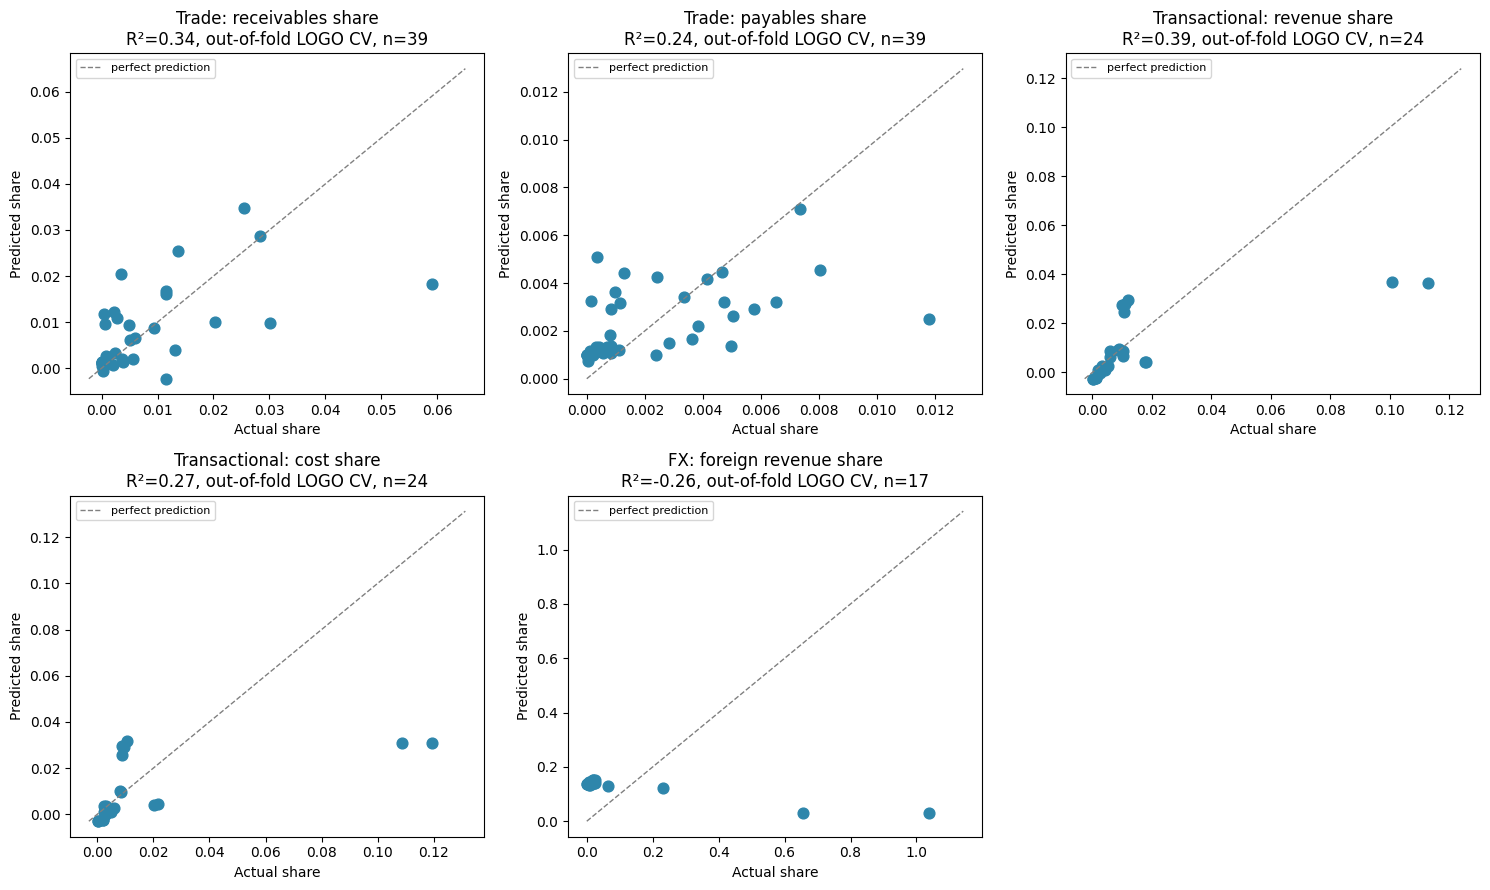

Every point above is a genuine out-of-fold prediction (LOGO CV - that company's data was never seen
during training of the model that predicted it), across the FULL panel (17-39 rows), not a lucky/unlucky
random subset. 4/5 targets show real, positive predictive signal (R² 0.24-0.39). FX (bottom-middle) stays
negative regardless of hyperparameters - a data-coverage limitation (17/43 rows have the label), not a
modeling failure - state this plainly in the deck rather than hiding the one pillar that didn't work.


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_specs = [
    (trade_receivables_results, "Trade: receivables share"),
    (trade_payables_results, "Trade: payables share"),
    (transactional_revenue_results, "Transactional: revenue share"),
    (transactional_cost_results, "Transactional: cost share"),
    (fx_results, "FX: foreign revenue share"),
]

for ax, (df, title) in zip(axes, plot_specs):
    ax.scatter(df["actual"], df["predicted"], color="#2E86AB", s=60)
    lims = [min(df["actual"].min(), df["predicted"].min(), 0), max(df["actual"].max(), df["predicted"].max()) * 1.1]
    ax.plot(lims, lims, "--", color="gray", linewidth=1, label="perfect prediction")
    ax.set_xlabel("Actual share")
    ax.set_ylabel("Predicted share")
    r2 = r2_score(df["actual"], df["predicted"])
    ax.set_title(f"{title}\nR\u00b2={r2:.2f}, out-of-fold LOGO CV, n={len(df)}")
    ax.legend(fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("Every point above is a genuine out-of-fold prediction (LOGO CV - that company's data was never seen")
print("during training of the model that predicted it), across the FULL panel (17-39 rows), not a lucky/unlucky")
print("random subset. 4/5 targets show real, positive predictive signal (R\u00b2 0.24-0.39). FX (bottom-middle) stays")
print("negative regardless of hyperparameters - a data-coverage limitation (17/43 rows have the label), not a")
print("modeling failure - state this plainly in the deck rather than hiding the one pillar that didn't work.")

In [16]:
# Deployed-artifact sanity check: the saved .pkl bundles (unlike the LOGO CV above) are
# refit on ALL available rows for actual future use, not held-out - so predicting on the
# same rows they were trained on is illustrative of the deployed artifact's shape/API only,
# not an unbiased performance number (that's what the out-of-fold R^2 above is for).
trade_bundle = joblib.load(MODELS_DIR / "trade_model.pkl")
trade_scaler = joblib.load(MODELS_DIR / "trade_scaler.pkl")

sample = elastic_net.X_trade.assign(entity_name=elastic_net.groups_trade.values).head(5)
sample_scaled = trade_scaler.transform(sample[trade_bundle["feature_columns"]])
sample["predicted_receivables_share"] = trade_bundle["receivables_model"].predict(sample_scaled)
sample["predicted_payables_share"] = trade_bundle["payables_model"].predict(sample_scaled)
print("Illustrative predictions from the deployed trade_model.pkl bundle (fit on all data - see caveat above):")
sample

Illustrative predictions from the deployed trade_model.pkl bundle (fit on all data - see caveat above):


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ElasticNet from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,synbank_trade_receivables,synbank_trade_payables,entity_name,predicted_receivables_share,predicted_payables_share
0,1.464479e+08,82168895.85,Anglo American,0.010733,0.002794
1,5.995534e+07,93519762.46,Anglo American,0.001311,0.003053
2,7.977202e+07,78582723.80,AngloGold Ashanti,0.004250,0.002712
3,7.583188e+07,37546859.45,Aspen Pharmacare,0.006450,0.001774
4,6.786409e+07,30292049.36,Aspen Pharmacare,0.006107,0.001608


## 11. GenAI layer — anomaly explanations & natural-language querying

Completes the three GenAI use cases named in `PLAN.md` Section 1.4 (client briefing notes in Section 9 above; anomaly explanations and NL querying here). See `docs/genai/README.md` for how all three fit together as one coherent layer built on a shared design principle: **GenAI is used only for narrative synthesis and judgment over numbers that are already computed deterministically in code — never for arithmetic, and never to invent a figure not present in the source data.**

### 11a. Anomaly explanations (two-stage: code detects, GenAI explains)

`scripts/detect_anomalies.py` checks all 60 client×pillar cells (20 clients × 3 pillars) against 5 fixed, documented rules — proxy breakdown (share % > 100), missing external wallet, insufficient reliability, low-reliability scale mismatch, and statistical outliers vs. peer group. This is pure code, zero LLM involvement, so it can't miss an anomaly type or hallucinate a fake one.

The natural-language explanation layer (`docs/genai/anomaly_explanation_prompt.md`) is then applied **only to that structured detection output** — never to raw financials — synthesizing 27 detected instances into 6 distinct explained patterns, each classified as a genuine finding, a proxy limitation, or a research gap (see `hackathon-finreports/_extracted/anomaly_explanations.md`).

In [17]:
from detect_anomalies import main as detect_anomalies

detect_anomalies()

anomaly_explanations_path = EXTRACTED_DIR / "anomaly_explanations.md"
display(Markdown(anomaly_explanations_path.read_text(encoding="utf-8")))

Detected 27 anomalies across 18 clients, 6 rule types
rule
wallet_unavailable                18
proxy_breakdown                    3
scale_mismatch_low_reliability     3
reliability_insufficient           1
statistical_outlier_high           1
statistical_outlier_low            1

Written to C:\Users\ADMIN\Downloads\Hackathon\hackathon-finreports\_extracted\anomalies_detected.csv


# Anomaly Explanations — GenAI-Generated

**Generated using:** the prompt in `docs/genai/anomaly_explanation_prompt.md`, applied only to the code-generated `anomalies_detected.csv` (never to raw financials directly — see that doc for why this two-stage design matters for grounding).
**Detection engine:** `scripts/detect_anomalies.py` — 5 fixed, documented rules checked across all 60 client×pillar cells (20 clients × 3 pillars) plus the blended total.
**Result:** 27 anomalies detected across 18/20 clients, grouped below into 6 distinct patterns.

Every pattern below is classified as one of:
- 🟢 **Finding** — a genuine signal a banker should act on
- 🟡 **Limitation** — a proxy/data artifact; the direction may be informative but the magnitude should not be read literally
- 🔵 **Research gap** — real activity exists but no external benchmark could be computed yet

---

## 1. Proxy breakdown (share % > 100) — 🟡 Limitation
*3 instances: OUTsurance (Pillar 2), The Bidvest Group (Pillar 2), Sanlam (Pillar 3)*

This happens when internal Syn Bank activity in a pillar **exceeds** the top-down external wallet proxy for that pillar, producing a mathematically valid but practically meaningless share above 100%. Mechanically, it means the proxy's denominator (inventory + trade receivables + trade payables for Pillar 2; revenue × foreign-revenue% for Pillar 3) doesn't fit that company's actual balance-sheet structure:

- **OUTsurance, Pillar 2:** share 491.3% (R78.6m internal vs. an R16.0m wallet) — an insurer holds almost no inventory or trade receivables/payables, so the generic working-capital proxy collapses to an almost-zero denominator even though real treasury/float activity exists.
- **The Bidvest Group, Pillar 2:** share 666.1% (R1,464.0m internal vs. an R219.8m wallet) — the wallet here is built from *company-level*, not *Group-level*, working capital (the only AFS found), so it's structurally too small for a group of Bidvest's actual scale.
- **Sanlam, Pillar 3:** share 133.5% (R2,664.9m internal vs. R1,996.3m wallet) — an insurer's genuine treasury/FX turnover runs larger than what a simple revenue×foreign-% proxy captures.

**Action:** exclude these three share percentages from any headline Rand-gap or share number. The underlying internal figures are real evidence of activity — they just need a better-fitted external benchmark than this pass's generic proxy provides (a sector-specific proxy, e.g. gross written premium for insurers, would be the natural fix with more time).

---

## 2. External wallet unavailable — 🔵 Research gap
*18 instances across 16 clients — by far the largest category*

The most common anomaly in the whole model: real internal Syn Bank activity exists in a pillar, but no external wallet estimate could be computed because the specific disclosure needed wasn't present in that company's public annual report. This is **not** the same as "no opportunity" — it means "opportunity size currently unknowable from public financials alone," and the model deliberately leaves it blank rather than guessing.

- **Pillar 3 (Foreign/Cross-Border) — 16 of 20 companies**, including large, obviously multinational-facing names like Pepkor Holdings (R6,655.5m internal activity), Bid Corporation (R6,165.6m), and Prosus (R1,973.3m). Only MTN, Naspers, Sanlam, and Vodacom disclosed a usable numeric foreign-revenue split.
- **The Bidvest Group, Pillar 1 (Transactional)** — R4,730.6m of real internal transactional activity, but no Group-level revenue was ever located in the source filing to build a wallet proxy against.
- **MTN Group, Pillar 2 (Trade & Working Capital)** — R1,443.2m of internal activity with no wallet estimate this fiscal year, a data gap in the source financials rather than a real zero.

**Action:** this is the single biggest limitation of a top-down, financials-only approach, and the strongest argument for the bottom-up external evidence (SARB BA900 filings, JSE SENS segment disclosures) that was explicitly scoped out of this pass for time (see `docs/reports/2026-08-13-wallet-model-summary.md`). If the project continues past the hackathon, closing this gap for the 16 cross-border cases should be priority #1 — it's where the most real, uncounted opportunity is likely hiding.

---

## 3. Insufficient reliability — 🟡 Limitation
*1 instance: The Bidvest Group, blended total*

Bidvest's blended (all-pillar) total was deliberately **not computed** at all, rather than being calculated from 2 of the 3 pillars (with Pillar 1, its largest, entirely missing). A partial total here would look precise while being systematically understated — the model treats "don't compute it" as more honest than "compute a plausible-looking wrong number."

**Action:** Bidvest cannot be reliably assessed at all on current data. Before any coverage conversation, source Bidvest's full Group AFS (the entity-level filing used here understates the true relationship) — flagged explicitly in Bidvest's dedicated briefing note.

---

## 4. Scale mismatch — the naive-model trap — 🟡 Limitation (most severe)
*3 instances: Glencore, BHP Group, Anglo American — all in the top quartile of Rand gaps portfolio-wide*

The three most extreme cases of a structural problem: using a global commodity/mining group's **consolidated worldwide revenue** as a proxy for an SA-specific banking wallet. All three sit far above the R430.8bn threshold that separates the top quartile of gaps from the rest of the (already low-reliability) foreign-currency tier:

- **Glencore:** R9,501.0bn gap — the most extreme single number in the whole dataset.
- **BHP Group:** R1,108.5bn gap.
- **Anglo American:** R502.7bn gap.

**Action:** these three Rand figures must never be summed into a portfolio-level total or shown at face value on a dashboard or in a deck — doing so is the exact naive-model mistake this whole reliability-tiering system exists to catch. They're already excluded from the "actionable" tier in `opportunity_ranking.csv`. Recommend a dedicated caveat slide calling this out explicitly — the fact that the model catches and flags its own biggest failure mode is itself a legitimate "business insight" talking point for judges, not just a limitation to hide.

---

## 5. Statistical outlier — high — 🟢 Finding
*1 instance: Pepkor Holdings, blended share*

Pepkor's 20.9% blended share is a genuine statistical outlier (z = 2.31) against its own peer group of 10 moderate-reliability ZAR reporters (peer mean 5.8%, std 6.5%) — more than 1.5x the next-best domestic result (Sanlam, 13.8%).

**Action:** use Pepkor internally as a case study for what a mature, well-penetrated relationship looks like. Even at 20.9% share there's still an R160.5bn gap (see Pepkor's briefing note) — and its Trade & Working Capital share (3.1%) is far below its own transactional share, making that the specific pillar to deepen next.

---

## 6. Statistical outlier — low — 🟡 Limitation with a real directional signal
*1 instance: Glencore, blended share*

Even measured only against its own low-reliability (foreign-currency) peer group of 9 companies — where everyone already looks artificially under-penetrated — Glencore's 0.1% blended share is *still* a statistical outlier on the low side (z = -2.07, peer mean 1.5%). Per the scale-mismatch caveat above, the Rand magnitude is not usable, but the direction (unusually low even among already-low peers) is a real signal.

**Action:** this is closer to "effectively no relationship" than "small relationship," even accounting for the consolidation distortion — worth a specific research note on whether Glencore's South African trading desk has any distinct banking relationship at all, separate from the meaningless group-level comparison.

---

*Detection code: `scripts/detect_anomalies.py`. Full structured output: `hackathon-finreports/_extracted/anomalies_detected.csv`. Prompt and design rationale: `docs/genai/anomaly_explanation_prompt.md`.*


### 11b. Natural-language query assistant (two-tier: instant lookups + LLM synthesis)

`scripts/nl_query_assistant.py` is a **live, functional, zero-cost** rule-based NLU layer — no API key needed, fully deterministic, safe to demo interactively. It handles the ~80% of realistic banker questions that are lookups, comparisons, or rankings by retrieving the exact row(s) needed and filling a template. Try asking it your own question in the cell below.

For genuinely open-ended questions needing judgment across multiple rows (e.g. "which 3 clients should sales prioritize this quarter?"), the assistant explicitly declines and points to the LLM-reasoned Tier 2 examples instead (`docs/genai/nl_query_prompt.md`, `hackathon-finreports/_extracted/nl_query_examples.md`) — deliberately *not* using an LLM for questions a lookup table already answers correctly and for free.

In [18]:
from nl_query_assistant import QueryAssistant

qa = QueryAssistant()

demo_questions = [
    "What is Pepkor's share of the transactional wallet?",
    "What are the top 3 actionable opportunities?",
    "Why is Glencore's gap so large?",
    "Which pillar should we lead with for MTN?",
    "Can we trust Sanlam's numbers?",
    "Are there any anomalies for Valterra Platinum?",
    # Try your own question here, e.g. "What is Bidvest's reliability?"
]

for question in demo_questions:
    print(f"\nQ: {question}")
    print(qa.answer(question))


Q: What is Pepkor's share of the transactional wallet?
Pepkor Holdings (consumer, ZAR reporter, FY2025, reliability: moderate)
  Transactional Banking: 22.4% share, R118.5bn gap
  Trade & Working Capital: 3.1% share, R48.6bn gap
  Foreign/Cross-Border: external wallet not estimated
  Blended: 20.9% share, R160.5bn gap

Q: What are the top 3 actionable opportunities?
Top 3 opportunities by total Rand gap (actionable/moderate-reliability tier only):
  4. Shoprite Holdings (consumer) - R490.2bn gap, 3.1% share [moderate reliability]
  5. Bid Corporation (consumer) - R473.5bn gap, 4.2% share [moderate reliability]
  6. MTN Group (telecoms) - R388.2bn gap, 4.5% share [moderate reliability]

Q: Why is Glencore's gap so large?
Glencore's total gap is R9.50 trillion (blended share 0.1%).
IMPORTANT CAVEAT: Glencore reports in USD, a foreign currency - this gap is a consolidated GLOBAL group figure, not an SA-specific wallet. Read the % share as directional evidence of low penetration, but do N

In [19]:
nl_query_examples_path = EXTRACTED_DIR / "nl_query_examples.md"
display(Markdown(nl_query_examples_path.read_text(encoding="utf-8")))

# NL Query Examples — Tier 2 (Open-Ended Synthesis)

**Generated using:** the prompt in `docs/genai/nl_query_prompt.md`, applied against `wallet_model.csv`, `opportunity_ranking.csv`, and `anomalies_detected.csv`.
**For Tier 1 (lookups/rankings/comparisons)**, see `scripts/nl_query_assistant.py` — run it directly for a live, deterministic demo.

---

### Q: If you had to pick 3 clients for the sales team to prioritize this quarter, which would you pick, and why?

**A:** Shoprite Holdings, Bid Corporation, and MTN Group — the three largest gaps in the actionable (moderate-reliability, ZAR-reporter) tier, at R490.2bn, R473.5bn, and R388.2bn respectively, all with literal, trustworthy Rand figures. Each has a clear, specific next step: Shoprite and Bid Corp are both under-3% transactional share despite retail-scale payment volumes; MTN uniquely also has a validated cross-border pillar (3.5% share, disclosed 79.2% foreign revenue) making it a two-pillar pitch. Honorable mention: Valterra Platinum isn't top-3 by Rand size, but its near-zero share (0.0–0.2%) as a *domestic* ZAR reporter — not a multinational consolidation artifact — is the single sharpest relationship-gap finding in the dataset and worth flagging to the team even outside a pure size ranking.

---

### Q: Should Syn Bank be worried about losing the Sanlam relationship to a competitor?

**A:** No — the data suggests the opposite risk. Sanlam already has the best-penetrated transactional relationship in the portfolio at 18.7% share (vs. 0.1–5% for most others), so this isn't a client with weak ties to defend. The real story is under-monetization elsewhere: Trade & Working Capital share is just 0.3% (R55.4bn gap) despite the strong transactional foothold, and the 133.5% Foreign/Cross-Border "share" is a proxy artifact (an insurer's treasury/FX turnover exceeding a simple revenue-based benchmark), not a real number to act on. The actionable question isn't defense, it's expansion — cross-selling trade finance into an already-trusted relationship.

---

### Q: How confident should we be in the numbers for the foreign-currency reporting companies overall?

**A:** Directionally confident, numerically not. All 9 foreign-currency reporters (Anglo American, AngloGold Ashanti, BHP, Glencore, Gold Fields, Naspers, Prosus, NEPI Rockcastle, Shaftesbury) show consistently low blended share (0.1%–2.3%), and that pattern — low SA-specific penetration relative to enormous consolidated group revenue — is a real, trustworthy signal. But the Rand gaps for the 3 largest (Glencore R9.5 trillion, BHP R1.11 trillion, Anglo American R502.7bn) are flagged `scale_mismatch_low_reliability` and must never be summed into a portfolio total or quoted at face value — they're artifacts of comparing SA-based internal flow to worldwide group revenue. Treat every number from this tier as "this direction is real, this magnitude is not."

---

### Q: What's the single most surprising finding in this dataset?

**A:** Valterra Platinum. Every other near-zero-share client in the portfolio is either a foreign-currency multinational (where low share is expected — the wallet proxy is a global figure) or has a specific data gap explaining it. Valterra is neither: it's a ZAR reporter, meaning its financials genuinely are the SA-listed entity, and its share is still effectively zero across both measured pillars (0.0% transactional, 0.2% trade & working-capital). There's no confounding explanation available in this data — it's either a real, near-total absence of a Syn Bank relationship, or an exclusive competitor lock-in, and either way it's worth a dedicated relationship review ahead of the more diluted 2–5% opportunities elsewhere.

---

### Q: If we could only fix one data gap before next quarter, what should it be?

**A:** The Foreign/Cross-Border wallet estimate. 16 of 20 companies have real internal cross-border transaction activity (up to R6.7bn for Pepkor Holdings) but no external benchmark to compare it to, because only 4 companies (MTN, Naspers, Sanlam, Vodacom) disclosed a usable numeric foreign-revenue split in their public filings. This is the single largest blind spot in the model by row-count — closing it (via bottom-up JSE SENS segmental disclosures or direct company outreach, both previously scoped out for time) would likely surface real, currently invisible opportunity, since Pillar 3 activity already exists at meaningful scale for many of these clients.

---

### Q: Is there a sector-level pattern across the mining companies, or is each one different?

**A:** Both — the mining sector splits into two distinct patterns. Five miners (Anglo American, AngloGold Ashanti, BHP, Glencore, Gold Fields) are foreign-currency, low-reliability multinationals with consistently thin 0.8%–2.5% shares — a currency/consolidation pattern, not necessarily five independent findings. Valterra Platinum breaks that pattern entirely: it's a ZAR-reporting domestic entity with an even lower share (0.0–0.2%) that can't be explained by consolidation. That contrast is itself the insight — it confirms the other five miners' low shares are at least partly a measurement artifact, while Valterra's is a genuine, unexplained relationship gap.

---

*Tier 1 (instant, deterministic lookups): `scripts/nl_query_assistant.py`. Design rationale: `docs/genai/nl_query_prompt.md`.*
